# NL-2 — Levels & the Continuum Memory System

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/nested-learning/nl2-levels-continuum-memory.ipynb)

**The question:** what do you get when you order *every* memory in a model by how often it updates?

Second module of the Nested Learning track. Prerequisites: foundations M1–M7, and [NL-1](nl1-test-time-learning.ipynb). Runs on CPU in seconds; PyTorch throughout.

By the end of this module you should be able to:

- Define a **level** by **update frequency** (Def. 2) and sort a model's changing parts into an ordered ladder — including the dependency tiebreak and same-level parallel components.
- Count the levels in the setups we already built: plain SGD (1), +momentum (2), linear attention (2), linear attention + momentum (3).
- Explain why a standard **Transformer is just the two frequency extremes** — attention at $\infty$, the MLP at $0$ — with the middle of the spectrum empty.
- See the **stability–plasticity tradeoff** a single update frequency forces, and why that *motivates* a continuum of timescales.
- Read the **Continuum Memory System** (CMS) as a chain of MLP memories at $k$ different frequencies (Eq. 70–71), and say why filling the spectrum helps continual learning.

> Grounding: [Nested Learning](https://arxiv.org/abs/2512.24695) (Behrouz, Razaviyayn, Zhong & Mirrokni, Dec 2025 — the same group as Titans, Miras and Atlas, a year on from Titans; *levels*, the $\succ$ ordering and the CMS are all its own coinages) §3.2 (Def. 2, levels & the $\succ$ ordering), §7.1 (CMS, Eq. 70–71). The $\infty$/$0$ reading of a Transformer is stated in §1 and cashed out in §8 (attention at $\infty$) and §7.1 (the MLP at $0$) — see §2's note.

> **Prerequisite math** — *orthogonality* and *effective rank* (why interference happens) are in the [linear-algebra primer](../../primers/linear-algebra.ipynb).

## Why this module exists — we have a pile of memories, now order them

[NL-1](nl1-test-time-learning.ipynb) closed on a provocation: it put a real optimizer *inside* the memory, and [M6](../../foundations/m6-optimizers-as-memory.ipynb) had already found a memory *inside* the optimizer. Between them there is no privileged number of learning loops in a model — so stop assuming and start counting.

Look back at what the foundations actually built. Every module added *a thing that changes over time*:

- the **in-context memory** $\mathcal M_t$ that rewrites itself every token (M1–M4, and NL-1's test-time learner),
- the **slow weights / projections** $W_\bullet$ that move once per training step (M2),
- the **momentum buffer** $\mathbf m_t$ that compresses the gradient stream (M6).

Classic deep learning files these under two headings — "architecture" and "optimizer" — as if they were different *kinds* of object. M6 already dissolved that split (the optimizer is a memory too). So what actually distinguishes these pieces? **Only one thing: how often each updates.** Sort them by update rate and the model's hidden structure falls out as a clean ladder — that ordering *is* Nested Learning's central object, and everything else (ICL, the Transformer's limits, CMS, HOPE) is a consequence.

## 1. What a level is — update frequency (Def. 2)

Set **one update over one data point** as the unit of time. A component's **frequency** $f_A$ is how many times it updates per unit ([NL](https://arxiv.org/abs/2512.24695) Def. 2 defines exactly this: "*its number of updates per unit of time*"). Then order components with $\succ$:

$$A\succ B\quad\text{("}A\text{ is faster")}\iff f_A>f_B\quad\textbf{or}\quad\big(f_A=f_B\ \text{and computing }B\text{ needs }A\big).$$

The second clause is a **dependency tiebreak**: two things that update equally often but where one is computed *from* the other are still on different levels. Two things that update equally often and *don't* depend on each other sit on the **same level, in parallel**. Then: **same frequency ⇒ same level; higher level ⇒ lower frequency.** Level 1 is the fastest-changing; the top level is the slowest ("pre-training").

The demo implements exactly this $\succ$ ordering and runs it on the setups we built.

In [5]:
# Faithful Def 2: A≻B if f_A > f_B, OR (f_A == f_B and B depends on A).
# level(X) = 1 + max(level(Y) for every Y faster than X); equal-freq & independent → same level.
def assign_levels(components):  # name -> (freq, set of deps)
    names = list(components)

    def faster(a, b):  # is a ≻ b ?
        fa, da = components[a]
        fb, db = components[b]
        return fa > fb or (fa == fb and a in db)  # b depends on a → a is faster

    level = {}
    for _ in range(len(names)):  # iterate to a fixed point
        for x in names:
            level[x] = 1 + max([level.get(y, 0) for y in names if faster(y, x)] or [0])
    return level


def show(title, comps):
    lv = assign_levels(comps)
    nlev = max(lv.values())
    print(f"{title}  →  {nlev} level(s)")
    for L in range(1, nlev + 1):
        members = [n for n in comps if lv[n] == L]
        tag = "   (parallel — same level)" if len(members) > 1 else ""
        print(f"   level {L}  (freq {comps[members[0]][0]}):  {', '.join(members)}{tag}")
    print()


T, S = "per-token", "per-step"
show("A: MLP + plain SGD", {"W": (S, set())})
show("B: MLP + SGD-momentum", {"momentum m": (S, set()), "W": (S, {"momentum m"})})
show("C: linear attention + SGD", {"in-context memory M_t": (T, set()), "projections W_qkv": (S, set())})
show(
    "D: linear attention + momentum",
    {"in-context memory M_t": (T, set()), "momentum m": (S, set()), "projections W_qkv": (S, {"momentum m"})},
)
show(
    "E: AdamW — two moments are PARALLEL on one level",
    {"1st moment m": (S, set()), "2nd moment v": (S, set()), "W": (S, {"1st moment m", "2nd moment v"})},
)

A: MLP + plain SGD  →  1 level(s)
   level 1  (freq per-step):  W

B: MLP + SGD-momentum  →  2 level(s)
   level 1  (freq per-step):  momentum m
   level 2  (freq per-step):  W

C: linear attention + SGD  →  2 level(s)
   level 1  (freq per-token):  in-context memory M_t
   level 2  (freq per-step):  projections W_qkv

D: linear attention + momentum  →  3 level(s)
   level 1  (freq per-token):  in-context memory M_t
   level 2  (freq per-step):  momentum m
   level 3  (freq per-step):  projections W_qkv

E: AdamW — two moments are PARALLEL on one level  →  2 level(s)
   level 1  (freq per-step):  1st moment m, 2nd moment v   (parallel — same level)
   level 2  (freq per-step):  W



Read the counts: plain SGD is **1 level**; momentum makes it **2** (the *optimizer* added a level, not the architecture — B); linear attention also makes **2**, but a *different* one — the per-token in-context memory is genuinely faster than the per-step projections (C); stack both and you get **3** (D). And AdamW shows the subtlety: its first and second moments update at the same rate and don't depend on each other, so they sit **side by side on one level** (E). Ordinary setups are *already* multi-level — NL just makes the ladder visible.

## 2. A Transformer is the two frequency *extremes*

Apply the ruler to a standard Transformer block and you get the paper's punchline:

- **Attention** keeps no parameters that update *within* a sequence; it is a **non-parametric** solution *re-solved from scratch at every token* over all the past. Its effective memory state changes every token → **frequency $\infty$**.
- The **MLP block** is **frozen during the sequence** — the same map is applied to every token; it only moves during pre-training → **frequency $0$**.

So a Transformer isn't "attention + MLP, two species." It is **one memory at the highest possible update frequency next to one at the lowest**, with *nothing in between*. The demo shows both facts directly: feed the same token at two positions and watch the MLP give an identical answer (frozen) while attention gives different answers (re-solved against a growing context).

::: {.callout-note collapse="true"}
## Where the paper actually says this — not where it says it will

[NL](https://arxiv.org/abs/2512.24695) §1 makes the claim in one sentence: "*Later, in Section 6, however, we show that in-context learning provides an extreme case of this design and in fact, Transformer architectures are based on two extreme frequencies of update: i.e., $\infty$ and $0$ for attention and MLP blocks, respectively.*"

Follow that pointer and you will not find it. §6 (*Takeaways and Revisiting Common Terms*) never mentions either frequency; the forward reference is broken. The two halves are delivered separately and elsewhere — attention at $\infty$ in **§8** ("*perfect memories … with frequency update of infinity as they are non-parametric solutions*"), the MLP at $0$ in **§7.1** ("*The conventional Transformer block … where $k=1$ and frequency of update is zero*"). We cite those rather than the promise.
:::

In [ ]:
import numpy as np, torch

torch.manual_seed(1)
d, T = 8, 12
Wmlp = torch.randn(d, d) / np.sqrt(d)  # frozen during the sequence
seq = torch.randn(T, d)
tok = torch.randn(d)
seq[3] = tok
seq[9] = tok  # SAME token at positions 3 and 9


def mlp(x):
    return torch.relu(x @ Wmlp.T)


def causal_attn(seq, i):  # non-parametric: recomputed over tokens 0..i
    q = seq[i]
    K = seq[: i + 1]
    w = torch.softmax(K @ q / np.sqrt(d), 0)
    return w @ K


print(f"MLP(tok) at pos 3 == at pos 9 : {torch.allclose(mlp(seq[3]), mlp(seq[9]))}   → frozen map, frequency 0")
print(
    f"attention(tok) pos 3 vs pos 9 : differ by {torch.norm(causal_attn(seq, 3) - causal_attn(seq, 9)):.3f}"
    f"   → state re-solved every token, frequency ∞"
)
print("A Transformer block = {freq ∞ (attention)}  +  {freq 0 (MLP)}, with the middle of the spectrum empty.")

MLP(tok) at pos 3 == at pos 9 : True   → frozen map, frequency 0
attention(tok) pos 3 vs pos 9 : differ by 0.094   → state re-solved every token, frequency ∞
A Transformer block = {freq ∞ (attention)}  +  {freq 0 (MLP)}, with the middle of the spectrum empty.


## 3. Why one frequency is not enough — the stability–plasticity tradeoff

Before filling that empty middle, see *why* you would want to. A single memory updated at one frequency faces an unavoidable tradeoff. Train it on task **A**, then on task **B** (same inputs, different target maps), and sweep its update period $C$ (how many steps between updates):

- update **often** (small $C$) → it tracks **B** perfectly but **overwrites A** (catastrophic forgetting);
- update **rarely** (large $C$) → it **retains A** but barely learns **B** (no plasticity).

There is no single $C$ that is good at both — *plasticity and stability pull in opposite directions along the frequency axis.* That is the whole argument for a **spectrum** of frequencies.

C (period)   errA (forgetting)   errB (plasticity)
         1               1.406               0.000
         5               1.340               0.044
        20               0.589               0.445
        60               0.124               0.724
       150               0.025               0.846
       300               0.008               0.895

small C: plastic but forgets (errA↑) · large C: stable but rigid (errB↑) · no single C wins both


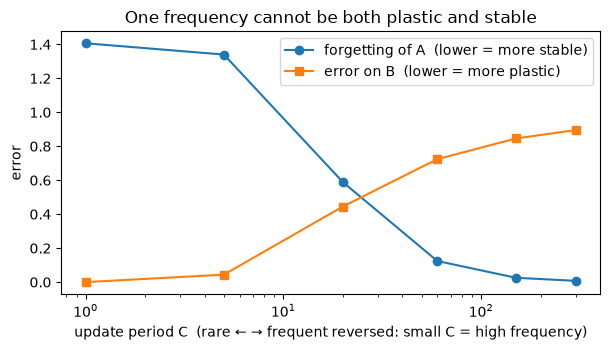

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

d = 16
g = torch.Generator().manual_seed(3)
WA = torch.randn(d, d, generator=g) / np.sqrt(d)
WB = torch.randn(d, d, generator=g) / np.sqrt(d)


def evalW(M, Wt, n=300):
    e = 0.0
    ge = torch.Generator().manual_seed(999)
    for _ in range(n):
        x = torch.randn(d, generator=ge)
        x /= x.norm()
        e += (M @ x - Wt @ x).norm().item()
    return e / n


def single(C, lr=1.0, steps=300, seed=5):
    M = torch.zeros(d, d)
    acc = torch.zeros(d, d)
    cnt = 0
    gen = torch.Generator().manual_seed(seed)
    step = 0
    a0 = None
    for Wt in (WA, WB):
        for _ in range(steps):
            x = torch.randn(d, generator=gen)
            x /= x.norm()
            acc += torch.outer(M @ x - Wt @ x, x)
            cnt += 1
            if (step + 1) % C == 0:  # chunk-AVERAGED gradient step (stable form of Eq.71)
                M = M - lr * acc / cnt
                acc = torch.zeros(d, d)
                cnt = 0
            step += 1
        if Wt is WA:
            a0 = evalW(M, WA)  # err on A right after learning A
    return a0, evalW(M, WA), evalW(M, WB)  # (errA_afterA, errA_afterB, errB)


Cs = [1, 5, 20, 60, 150, 300]
forget, plastic = [], []
print(f"{'C (period)':>10}{'errA (forgetting)':>20}{'errB (plasticity)':>20}")
for C in Cs:
    a0, a1, b = single(C)
    forget.append(a1 - a0)
    plastic.append(b)
    print(f"{C:>10}{a1 - a0:>20.3f}{b:>20.3f}")
print("\nsmall C: plastic but forgets (errA↑) · large C: stable but rigid (errB↑) · no single C wins both")

plt.figure(figsize=(6.2, 3.6))
plt.semilogx(Cs, forget, "-o", label="forgetting of A  (lower = more stable)")
plt.semilogx(Cs, plastic, "-s", label="error on B  (lower = more plastic)")
plt.xlabel("update period C  (rare ← → frequent reversed: small C = high frequency)")
plt.ylabel("error")
plt.title("One frequency cannot be both plastic and stable")
plt.legend()
plt.tight_layout()
plt.show()

## 4. The Continuum Memory System — fill the spectrum (Eq. 70–71)

The fix writes itself: don't pick one frequency — use **many**. The **Continuum Memory System** is a chain of MLP memories at $k$ different frequencies $f_1,\dots,f_k$ ([NL](https://arxiv.org/abs/2512.24695) Eq. 70):

$$\mathbf y_t=\text{MLP}^{(f_k)}\big(\dots\text{MLP}^{(f_1)}(\mathbf x_t)\big),$$

where block $\ell$ carries a chunk size $C^{(\ell)}:=\max_i C^{(i)}/f_\ell$ — the higher its frequency, the shorter its chunk — and updates only at chunk boundaries, accumulating over the chunk (Eq. 71):

$$\theta^{(f_\ell)}_{i+1}=\theta^{(f_\ell)}_i-\!\!\sum_{t=i-C^{(\ell)}}^{i}\!\!\eta^{(\ell)}_t\,f\big(\theta^{(f_\ell)}_t;\mathbf x_t\big)\quad\text{when }i\equiv 0\ (\mathrm{mod}\ C^{(\ell)}),\ \text{else frozen}.$$

Here $f(\cdot)$ is, in the paper's words, "*the error component of an arbitrary optimizer*" — read $f=\nabla\mathcal L$ and you have the plain gradient-descent instance it names, which is what the demo runs. A **standard Transformer is the degenerate case $k=1$** with frequency $0$ — one block, never updated in-sequence. CMS keeps the fast end *and* the slow end *and* the middle. The demo builds the chain and instruments the cadence: count how often each level updates and how far each moves over a stream.

::: {.callout-warning collapse="true"}
## Which end of the chain is the fast one? The paper indexes it both ways.

§3.2's convention is explicit — "*the higher the level is, the lower its frequency*" — so level 1 is the **fastest**. That is the convention §1 above uses.

§7.1 indexes the CMS chain the other way. Two of its own statements force it: the chunk size $C^{(\ell)}:=\max_i C^{(i)}/f_\ell$ makes a *larger* $f_\ell$ a *shorter* chunk, and Eq. 73 then says "*$\mathcal C^{(1)}$ is the context length of the MLP block in the **lowest frequency** level*" — pinning $f_1$ as the **slowest**. So in Eq. 70 the input meets the slowest block first and the fastest last. §7.1's continual-learning argument needs that reading too: knowledge forgotten by $\text{MLP}^{(f_s)}$ survives in $\text{MLP}^{(f_{s'})}$ "*where $s'<s$*", which only means "in the slower blocks" if $f_1$ is the slowest.

The paper never reconciles the two, so we write $f_1,\dots,f_k$ without asserting an order — nothing in this module turns on it. Just don't carry a "$f_1>\dots>f_k$" into §7.1: it is the reverse of what §7.1's own equations say.
:::

In [ ]:
import numpy as np
import torch

torch.manual_seed(2)
T, d = 128, 8
periods = [1, 8, 64]  # C for fast → slow levels
M = [torch.zeros(d, d) for _ in periods]
acc = [torch.zeros(d, d) for _ in periods]
cnt = [0] * len(periods)
updates = [0] * len(periods)
movement = [0.0] * len(periods)
gen = torch.Generator().manual_seed(7)
Wstar = torch.randn(d, d) / np.sqrt(d)

for step in range(T):
    x = torch.randn(d, generator=gen)
    x /= x.norm()
    err = sum(Ml @ x for Ml in M) - Wstar @ x  # head-wise CMS: output = Σ levels (Eq.74)
    for l, Cl in enumerate(periods):
        acc[l] += torch.outer(err, x)
        cnt[l] += 1
        if (step + 1) % Cl == 0:  # chunk boundary → update this level
            upd = acc[l] / cnt[l]
            M[l] = M[l] - 0.3 * upd
            movement[l] += 0.3 * upd.norm().item()
            acc[l] = torch.zeros(d, d)
            cnt[l] = 0
            updates[l] += 1

for l, Cl in enumerate(periods):
    print(f"level {l}  (period C={Cl:>2}):  {updates[l]:>3} updates / {T} steps,   cumulative |Δθ| = {movement[l]:.2f}")
print("\nfast level churns every step (plastic, short-term store); slow level barely moves (persistent store).")

level 0  (period C= 1):  128 updates / 128 steps,   cumulative |Δθ| = 7.47
level 1  (period C= 8):   16 updates / 128 steps,   cumulative |Δθ| = 0.43
level 2  (period C=64):    2 updates / 128 steps,   cumulative |Δθ| = 0.04

fast level churns every step (plastic, short-term store); slow level barely moves (persistent store).


**Why this helps continual learning (§7.1).** Treat each block as a knowledge store. When you update a fast block, it can forget — but *the forgotten knowledge still lives in the slower blocks*, which update rarely. And because the blocks' initial states are tied through backpropagation, a slow block can **circle that knowledge back** into a fast block later — "*a loop through time dimension, and so hardly forgetting important knowledge*", in the paper's words. The fast end gives plasticity; the slow end gives persistence; together they beat any single point on §3's tradeoff curve.

> **Honest scope of the demo.** The cells above show the two *ingredients* — the frequency ladder (§1, §4) and the stability–plasticity tradeoff it spans (§3) — with linear memories, where they are crisp. The *full* continual-learning win needs the **nonlinear, nested** CMS (MLP blocks, per-context re-initialization, the backprop circle-back); a linear head-wise sum can't show it, because the fast level dominates the readout and re-forgets. That nonlinear assembly is exactly what [NL-3](nl3-hope.ipynb) puts together. We flag this rather than overclaim it.

## 5. A second payoff — levels are a new axis of *computational depth*

Stacking more *layers* does not reliably let a model execute more complex algorithms — a Transformer's program is fixed once trained, and its computational depth is bounded (§1, §8, grounded in the state-tracking / circuit-complexity literature). NL's route to more depth is **more levels, not more layers**: each added level is extra computation *within* the forward pass (higher-order in-context learning, loops, self-modification).

A useful caveat to keep honest: "more computational depth" can be bought in *two* different places — in **token space** (chain-of-thought / reasoning models spend more forward passes across a longer generated sequence) or in **latent / within-pass depth** (loops, recurrent state, **NL's nested levels**). NL sells the *latent-depth* route; it does **not** discuss chain-of-thought. They are sibling ways to "run a longer program," not the same claim — worth not conflating.

## 6. The ladder, in one breath

A model is a **stack of memories sorted by update speed.** Plain SGD on an MLP is one level; momentum makes the *optimizer* contribute a second; linear attention makes the *architecture* contribute a fast in-context level; a Transformer is just the two frequency extremes ($\infty$ and $0$) with the middle empty. A single frequency can't be both plastic and stable, so you fill the middle with a **continuum** of MLP memories (CMS) — fast levels adapt and forget, slow levels persist, and the loop between them resists catastrophic forgetting.

Two consequences worth naming: **in-context learning is demystified** — it is simply "having more than one level," a fast level adapting on top of a well-trained slow one; and **computational depth** gets a new knob (levels, not layers). What remains is to stack the *self-modifying* memory (M5's SRWM, NL-1's Titans) **onto** this continuum — a fast level that rewrites its own update rule, sitting in a spectrum of slower stores. That assembly is **HOPE**, and it is [NL-3](nl3-hope.ipynb).

## Code walkthrough — where this lives

- [`levels.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/levels.py) — the level/frequency bookkeeping, made explicit: a `LevelSpec` carries each level's update period, a `LevelClock` decides when each one fires, and `levels_in_frequency_order()` is the $\succ$ ordering turned into code.
- [`cms.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/cms.py) — the chain of Eq. 70: one residual MLP block per level, applied in sequence. Worth knowing what is *not* here — the chunked per-level updates of Eq. 71. `cms.py` only stacks the blocks; the accumulate-over-$C^{(\ell)}$-tokens-then-step logic lives inside the forward pass in [`hope/block.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/hope/block.py), which [NL-3](nl3-hope.ipynb) walks through.
- [the from-scratch HOPE](https://github.com/obekt/HOPE-nested-learning) — its stack of `ContinuumMemoryBlock`s is a genuine three-frequency CMS (`cms_tiers` sets update periods 1, 4 and 16, each with its own optimizer). Note it is *attention-free*: there the CMS chain **is** the feed-forward stack rather than a replacement for a Transformer's MLP.

The two repos are independent community reimplementations, not the authors' code.

## Exit check

**1. How is a "level" defined, and what are the two ways two components can share or split a level?**
A level is a set of components with the same **update frequency** $f$ (updates per data point, NL Def. 2), ordered so higher level = lower frequency (§1). Two components **split** into different levels either because their frequencies differ, or because they update equally often but one is **computed from** the other (the dependency tiebreak: $A\succ B$ if $f_A=f_B$ and $B$ needs $A$). Two components that update equally often and are **independent** share one level, in parallel — AdamW's first and second moments are the canonical example (§1, demo E).

**2. Why is a Transformer block "two frequency extremes," and which is which?**
Attention keeps no in-sequence parameters — it is **re-solved from scratch every token** over the whole past, so its state changes at **frequency $\infty$**; the MLP is **frozen during the sequence** (same map for every token, moves only in pre-training), so **frequency $0$** (§2). The demo confirms it: the MLP returns an identical output for the same token at two positions, while attention returns different outputs. A Transformer is the two endpoints of the frequency spectrum with the middle empty.

**3. What tradeoff makes a single update frequency insufficient, and how does CMS resolve it?**
The **stability–plasticity tradeoff** (§3): a memory updated often is plastic but forgets old tasks (catastrophic forgetting); updated rarely it retains but cannot learn new ones — and no single update period $C$ is good at both. **CMS** (Eq. 70–71) resolves it by using a **chain of MLP memories at $k$ different frequencies** (§4): fast levels supply plasticity, slow levels supply persistence, and because forgotten knowledge survives in slower blocks (and can be circled back via backprop), the system resists forgetting. A Transformer is the degenerate $k=1,\ f=0$ case.

**4. In what sense do "levels" add computational depth, and what is the honest boundary of that claim?**
Adding **levels** (not layers) adds computation *within* a forward pass — higher-order in-context learning, loops, self-modification — which is NL's route to executing more complex algorithms (§5). The honest boundary: this is the **latent / within-pass** depth axis; it is distinct from the **token-space** depth that chain-of-thought / reasoning models buy by generating more tokens. NL advocates the former and does not discuss the latter; they are siblings, not the same claim.

---

**Next → [NL-3](nl3-hope.ipynb), HOPE.** We finally assemble everything: take the **self-modifying** sequence memory (M5's SRWM, NL-1's Titans, optimized with M6's DGD) and drop it into this **continuum** of MLP memories. The fast level rewrites its own update rule while a spectrum of slower levels holds persistent knowledge — one continual-learning architecture, every piece of the course in its place.